EMOTION CLASSIFICATION WITH RNN,LSTMs & GRUs


In [5]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# data set load help this library
from datasets import load_dataset

# Load the dataset and use the imported function
emotion_data = load_dataset('dair-ai/emotion')

In [7]:
train_text=emotion_data['train']['text']
train_label=emotion_data['train']['label']
test_text=emotion_data['test']['text']
test_label=emotion_data['test']['label']

In [8]:
label_names=emotion_data['train'].features['label'].names

In [9]:
df_train=pd.DataFrame({
    'text':train_text,
    'label':[label_names[i] for i in train_label]
}


          )

In [10]:
for i in train_label:
    print(label_names[i])

df_test=pd.DataFrame({
    'text':test_text,
    'label':[label_names[i] for i in test_label]
})

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [11]:
df_train.head()


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [12]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

EDA

C:\Users\user\AppData\Local\Temp\ipykernel_18304\4031229652.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index,palette='rainbow')


<Axes: xlabel='label', ylabel='count'>

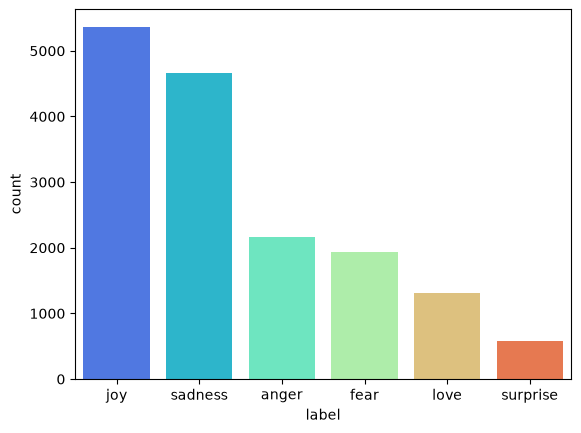

In [13]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index,palette='rainbow')

this dataset highly class imbalance 

using NLP

In [14]:


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train["text"])
train_sequence = tokenizer.texts_to_sequences(df_train["text"])

test_sequence = tokenizer.texts_to_sequences(df_test["text"])
padded_train_sequence=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')
padded_train_sequence

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]],
      shape=(16000, 50), dtype=int32)

In [15]:
train_labels=np.array(train_label)
train_labels
test_labels=np.array(test_label)
num_classes=len(np.unique(train_labels))
num_classes
print(f"Vocabulary size:{len(tokenizer.word_index)}")
print(f"max sentence length:{padded_train_sequence.shape[1]}")

Vocabulary size:15213
max sentence length:50


In [16]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_dict = dict(enumerate(class_weights))
class_weights_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [17]:
from tensorflow.keras.callbacks import EarlyStopping
early_stoping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

MODEL-1 RNN

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Embedding,Dense,Dropout,LSTM,GRU

rnn_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5), # hiddent layer 50 percent dropout that to less chance of overfitting
    SimpleRNN(units=64),
    Dropout(0.5), # hiddent layer 50 percent dropout that to less chance of overfitting

    Dense(units=num_classes,activation='softmax') #softmax output layer

])


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [19]:
rnn_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])
rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stoping]
)
rnn_loss,rnn_accuracy = rnn_model.evaluate(padded_test_sequence,test_labels)
print(f"RNN Loss:{rnn_loss}")
print(f"RNN Accuracy:{rnn_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.1618 - loss: 2.0006 - val_accuracy: 0.1285 - val_loss: 1.7755
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.1462 - loss: 1.8772 - val_accuracy: 0.0485 - val_loss: 1.7674
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1366 - loss: 1.8279 - val_accuracy: 0.1280 - val_loss: 1.7677
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1364 - loss: 1.8073 - val_accuracy: 0.0610 - val_loss: 1.8544
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.1395 - loss: 1.8029 - val_accuracy: 0.1175 - val_loss: 1.7962
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0485 - loss: 1.7674
RNN Loss:1.767417550086975
RNN Accuracy:0.048500001430511475


In [20]:
lstm_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    LSTM(units=128,return_sequences=True),
    Dropout(0.5), # hiddent layer 50 percent dropout that to less chance of overfitting
    LSTM(units=64),
    Dropout(0.5), # hiddent layer 50 percent dropout that to less chance of overfitting

    Dense(units=num_classes,activation='softmax') #softmax output layer

])


In [21]:
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stoping]
)
lstm_loss,lstm_accuracy =lstm_model.evaluate(padded_test_sequence,test_labels)
print(f"LSTM Loss:{lstm_loss}")
print(f"LSTM Accuracy:{lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - accuracy: 0.1467 - loss: 1.7949 - val_accuracy: 0.0810 - val_loss: 1.7907
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 95ms/step - accuracy: 0.1494 - loss: 1.7937 - val_accuracy: 0.2910 - val_loss: 1.7684
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 98ms/step - accuracy: 0.1761 - loss: 1.7932 - val_accuracy: 0.0805 - val_loss: 1.7925
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 95ms/step - accuracy: 0.1781 - loss: 1.7822 - val_accuracy: 0.2070 - val_loss: 1.7811
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 96ms/step - accuracy: 0.2652 - loss: 1.6662 - val_accuracy: 0.2925 - val_loss: 1.5794
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 99ms/step - accuracy: 0.3573 - loss: 1.3595 - val_accuracy: 0.3180 - val_loss: 1.2482
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step - accuracy: 0.5601 - loss: 1.0249 - val_accuracy: 0.6455 - val_loss: 0.9025
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.6877 - loss: 0.8202 -

GRU STANDARD ()

In [22]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')  # output layer
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stoping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU LOSS:{gru_loss}")
print(f"GRU accuracy:{gru_accuracy}")

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 100ms/step - accuracy: 0.1608 - loss: 1.7959 - val_accuracy: 0.2905 - val_loss: 1.7299
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step - accuracy: 0.1498 - loss: 1.7952 - val_accuracy: 0.3470 - val_loss: 1.7620
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step - accuracy: 0.1644 - loss: 1.7948 - val_accuracy: 0.0345 - val_loss: 1.7975
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - accuracy: 0.1561 - loss: 1.7927 - val_accuracy: 0.0820 - val_loss: 1.8031
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2905 - loss: 1.7299
GRU LOSS:1.7299171686172485
GRU accuracy:0.2904999852180481


In [23]:
result_df=pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Test Loss':[rnn_loss,lstm_loss,gru_loss],
    'Test Accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
}).sort_values(by='Test Accuracy',ascending=False)
result_df


,Model,Test Loss,Test Accuracy
1,LSTM,0.418477,0.8755
2,GRU,1.729917,0.2905
0,RNN,1.767418,0.0485


GRU ADHVANCE VERSION IT (Bidirection -> left to right || right to left)

In [24]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.fit(
    padded_train_sequence,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_data=(padded_test_sequence, test_labels),
    class_weight=class_weights_dict,
    callbacks=[early_stoping]
)
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 166ms/step - accuracy: 0.9492 - loss: 0.1323 - val_accuracy: 0.9245 - val_loss: 0.2038
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 92s 184ms/step - accuracy: 0.9669 - loss: 0.0934 - val_accuracy: 0.9240 - val_loss: 0.2407
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 167ms/step - accuracy: 0.9727 - loss: 0.0764 - val_accuracy: 0.9220 - val_loss: 0.2534
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 145s 172ms/step - accuracy: 0.9795 - loss: 0.0567 - val_accuracy: 0.9185 - val_loss: 0.2925
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9245 - loss: 0.2038
BiGRU Loss: 0.20380711555480957
BiGRU Accuracy: 0.9244999885559082


In [31]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9245 - loss: 0.2038
BiGRU Loss: 0.20380711555480957
BiGRU Accuracy: 0.9244999885559082


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step


<Axes: >

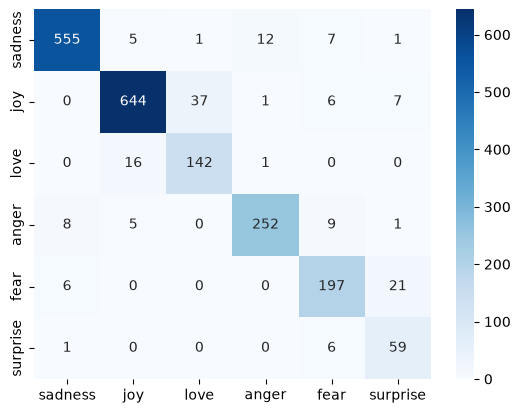

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
BiGRU_predictions=BiGRU.predict(padded_test_sequence)
sns.heatmap(confusion_matrix(test_labels,np.argmax(BiGRU_predictions, axis=1)),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

In [37]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences(sample_sequences,maxlen=50,padding='post')
sample_predictions=np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)
sample_predictions
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}")
    print(f"Predicted Emotion: {label_names[sample_predictions[i]]}")
    print("------------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy
------------------------------
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
------------------------------
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
------------------------------
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
------------------------------
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise
------------------------------


In [38]:

import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)